# HealthConnect Clinic
## Week 5 — Exploratory Analysis, KPI Development & Business Insights
**Track:** Data Analytics
**Project:** HealthConnect Clinic Experience Lab
**Project Focus:** Improving Patient Appointment Attendance and Healthcare Support
**Tools:** Python, Jupyter Notebook
---
## 1. Week 4 → Week 5 Transition
Week 4 focused on understanding the HealthConnect appointment dataset, assessing data quality, identifying relevant variables, defining business questions and proposing potential Key Performance Indicators (KPIs).
Week 5 builds directly on this foundation by moving from initial data assessment to practical exploratory analysis, KPI calculation and business insight development.
The main analytical objective remains understanding appointment attendance, no-shows and cancellations and identifying patterns that may help HealthConnect Clinic improve appointment attendance and reduce missed appointments.
The five KPIs proposed during Week 4 are considered for calculation and analysis in Week 5:
1. No-Show Rate
2. Attendance Rate
3. Cancellation Rate
4. Reminder Coverage Rate
5. Repeat No-Show Rate
The exploratory analysis will use the business questions established during Week 4 to investigate appointment characteristics, patient characteristics, previous appointment history, reminders, waiting time, distance to the clinic and appointment outcomes.

# 2. Data Preparation
The HealthConnect Appointment Dataset was reviewed before conducting exploratory analysis.
The preparation stage focused on confirming the structure of the dataset, checking data types, reviewing missing values, checking duplicate records, validating important categorical variables and documenting relevant data-quality observations.
The original dataset was preserved. A separate working copy was created for Week 5 analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("HealthConnect_Appointment_Data.csv")

df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 2.1 Working Dataset
A working copy of the original dataset was created so that any analytical transformations or derived variables would not modify the original HealthConnect appointment dataset.

## 2.1 Data Types
The data types of the variables were reviewed to ensure that categorical, numeric and date-related variables were stored appropriately for analysis.

In [2]:
# Create a working copy for Week 5 analysis
analysis_df = df.copy()
print("Original dataset shape:", df.shape) 
print("Analysis dataset shape:", analysis_df.shape)

Original dataset shape: (5000, 18)
Analysis dataset shape: (5000, 18)


In [3]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [4]:
analysis_df.dtypes

appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

## 2.3 Missing Values
Missing values were reviewed to determine whether they represented potential data-quality problems or expected values based on the meaning of the variables.
The analysis identified missing values in reminder_channel, distance_to_clinic_km and waiting_time_minutes.
Missing reminder channels are expected when no reminder was sent, while missing distance and waiting-time values were retained and considered when interpreting the analysis.

In [5]:
missing_values = analysis_df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(analysis_df) * 100).round(2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


## 2.4 Duplicate Records
Duplicate records were checked at both the row level and appointment ID level to ensure that the same appointment was not represented multiple times.

In [6]:
print("Duplicate rows:", analysis_df.duplicated().sum())

print(
    "Duplicate appointment IDs:",
    analysis_df["appointment_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate appointment IDs: 0


## 2.5 Data Preparation Summary
The dataset contains 5,000 appointment records across 18 variables.
No duplicate rows or duplicate appointment IDs were identified.
Missing values were present in distance_to_clinic_km, waiting_time_minutes and reminder_channel. Missing reminder channels are consistent with appointments where no reminder was sent and therefore were not treated as errors.
The original dataset was preserved and a separate working copy was used for Week 5 analysis.
No records were unnecessarily deleted during preparation.

# 3. Exploratory Data Analysis
## 3.1 Overall Appointment Outcomes
The first stage of the exploratory analysis examines the overall distribution of appointment outcomes.
This provides a baseline understanding of how many appointments were attended, missed or cancelled.

In [7]:
outcome_summary = (
    analysis_df["appointment_outcome"]
    .value_counts()
    .to_frame("Count")
)

outcome_summary["Percentage"] = (
    outcome_summary["Count"] / len(analysis_df) * 100
).round(2)

outcome_summary

,Count,Percentage
appointment_outcome,,
No-Show,2423,48.46
Attended,2314,46.28
Cancelled,263,5.26


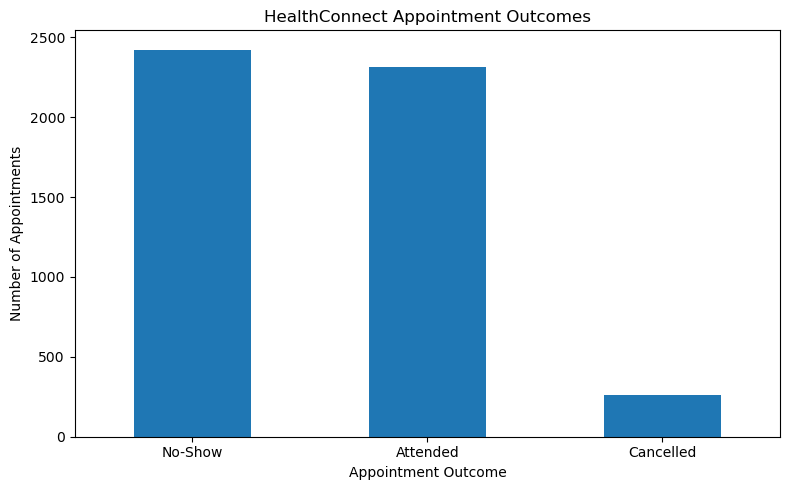

In [8]:
outcome_counts = analysis_df["appointment_outcome"].value_counts()

plt.figure(figsize=(8, 5))
outcome_counts.plot(kind="bar")

plt.title("HealthConnect Appointment Outcomes")
plt.xlabel("Appointment Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation
No-shows represent the largest appointment outcome category in the dataset, followed by attended appointments. Cancellations represent a much smaller proportion of scheduled appointments.
The relatively high proportion of no-shows indicates that missed appointments are an important area for further investigation.

## 4.1 Reminder Activity and Appointment Outcomes
The relationship between reminder activity and appointment outcomes was examined to determine whether attendance and no-show patterns differ between appointments where a reminder was sent and those where no reminder was recorded.
This analysis describes an association within the dataset and does not establish that reminders directly caused a change in attendance.

In [9]:
reminder_outcomes = pd.crosstab(
    analysis_df["reminder_sent"],
    analysis_df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

reminder_outcomes

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.68,5.93,51.39
Yes,47.63,5.01,47.36


### Interpretation
Appointments where a reminder was sent had a lower no-show rate than appointments where no reminder was sent.
The no-show rate was approximately 47.36% for appointments with reminders compared with 51.39% for appointments without reminders.
This represents an observed difference of approximately 4 percentage points. The result suggests that reminder activity should be investigated further as part of HealthConnect's appointment management strategy.

In [10]:
channel_outcomes = pd.crosstab(
    analysis_df["reminder_channel"],
    analysis_df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

channel_outcomes

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,46.53,5.07,48.41
SMS,49.60,4.65,45.75
WhatsApp,44.60,5.63,49.77


### Interpretation
Appointment outcomes were also compared across reminder channels.
SMS showed the lowest observed no-show rate among the recorded reminder channels, while WhatsApp showed a higher observed no-show rate.
These differences represent patterns within the available dataset and should not be interpreted as evidence that one communication channel causes better attendance.

## 5.1 Previous No-Show History
Previous appointment history was analysed to determine whether patients with a history of previous no-shows also show different outcomes for subsequent appointments.
This analysis is important because identifying repeat no-show patterns may help HealthConnect identify groups that require additional appointment support.

In [11]:
analysis_df["previous_no_show_flag"] = np.where(
    analysis_df["previous_no_shows"] > 0,
    "Previous No-Show",
    "No Previous No-Show"
)

previous_no_show_summary = pd.crosstab(
    analysis_df["previous_no_show_flag"],
    analysis_df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

previous_no_show_summary

appointment_outcome,Attended,Cancelled,No-Show
previous_no_show_flag,,,
No Previous No-Show,50.46,6.03,43.51
Previous No-Show,40.40,4.18,55.41


## Interpretation
Appointments associated with patients who had at least one previous no-show had a higher observed no-show rate than appointments associated with patients who had no previous no-show history.
The no-show rate was approximately 55.41% among appointments with a previous no-show history compared with 43.51% among those without one.
This indicates a meaningful association between previous no-show history and future appointment outcomes in the dataset.

## 6.1 Appointment Type
Appointment outcomes were analysed across different appointment types to determine whether attendance and no-show patterns vary according to the type of service scheduled.

In [12]:
appointment_type_outcomes = pd.crosstab(
    analysis_df["appointment_type"],
    analysis_df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

appointment_type_outcomes

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,45.87,4.38,49.75
Follow-up,43.35,5.42,51.23
General Consultation,48.27,5.08,46.64
Specialist Consultation,46.56,6.00,47.44


In [13]:
appointment_type_no_show = (
    analysis_df.groupby("appointment_type")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame("No-Show Rate (%)")
)

appointment_type_no_show

,No-Show Rate (%)
appointment_type,
Follow-up,51.23
Diagnostic Test,49.75
Specialist Consultation,47.44
General Consultation,46.64


### Interpretation
No-show rates vary across appointment types.
The differences suggest that appointment type should be considered when investigating missed appointments and when designing targeted appointment management strategies.

## 7.1 Appointment Day
Appointment outcomes were compared across the days of the week to identify whether no-show patterns vary according to the scheduled appointment day.

In [14]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_no_show = (
    analysis_df.groupby("appointment_day")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .reindex(day_order)
    .to_frame("No-Show Rate (%)")
)

day_no_show

,No-Show Rate (%)
appointment_day,
Monday,49.64
Tuesday,47.02
Wednesday,49.66
Thursday,48.98
Friday,46.57
Saturday,46.82
Sunday,50.47


## 8.1 Appointment Time
Appointment outcomes were analysed across morning, afternoon and evening appointments to determine whether the time of day is associated with different attendance patterns.

In [15]:
time_order = ["Morning", "Afternoon", "Evening"]

time_no_show = (
    analysis_df.groupby("appointment_time")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .reindex(time_order)
    .to_frame("No-Show Rate (%)")
)

time_no_show

,No-Show Rate (%)
appointment_time,
Morning,48.14
Afternoon,48.38
Evening,49.78


## 9.1 Booking Lead Time
Booking lead time was analysed to investigate whether appointments booked further in advance show different no-show patterns from appointments scheduled closer to the booking date.
Lead-time groups were created for analytical comparison only and do not represent changes to the original data.

In [16]:
analysis_df["lead_time_group"] = pd.cut(
    analysis_df["booking_lead_days"],
    bins=[-1, 7, 30, 90, np.inf],
    labels=["0–7 days", "8–30 days", "31–90 days", "91+ days"]
)

lead_time_no_show = (
    analysis_df.groupby(
        "lead_time_group",
        observed=False
    )["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .to_frame("No-Show Rate (%)")
)

lead_time_no_show

,No-Show Rate (%)
lead_time_group,
0–7 days,27.81
8–30 days,40.21
31–90 days,60.49
91+ days,NaN


## 10.1 Distance to Clinic
Distance to the clinic was examined to determine whether appointment outcomes differ across patients travelling different distances.
Missing distance values were retained rather than being replaced without evidence.

In [17]:
analysis_df["distance_group"] = pd.cut(
    analysis_df["distance_to_clinic_km"],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=["≤2 km", "2–5 km", "5–10 km", "10+ km"]
)

distance_no_show = (
    analysis_df.groupby(
        "distance_group",
        observed=False
    )["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .to_frame("No-Show Rate (%)")
)

distance_no_show

,No-Show Rate (%)
distance_group,
≤2 km,51.06
2–5 km,45.28
5–10 km,46.51
10+ km,51.02


## 11.1 Waiting Time
Waiting time was examined to determine whether appointment outcomes vary across different waiting-time groups.
Because some waiting-time values are missing, the results should be interpreted with this limitation in mind.

In [18]:
analysis_df["waiting_time_group"] = pd.cut(
    analysis_df["waiting_time_minutes"],
    bins=[-np.inf, 15, 30, 60, np.inf],
    labels=["≤15 min", "16–30 min", "31–60 min", "60+ min"]
)

waiting_no_show = (
    analysis_df.groupby(
        "waiting_time_group",
        observed=False
    )["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .to_frame("No-Show Rate (%)")
)

waiting_no_show

,No-Show Rate (%)
waiting_time_group,
≤15 min,47.06
16–30 min,49.19
31–60 min,47.63
60+ min,66.67


## 12.1 Age Group
Appointment outcomes were compared across patient age groups to identify whether attendance and no-show patterns differ across demographic groups.

In [19]:
age_no_show = (
    analysis_df.groupby("age_group")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame("No-Show Rate (%)")
)

age_no_show

,No-Show Rate (%)
age_group,
55-64,50.75
25-34,50.70
18-24,50.18
35-44,48.35
45-54,48.05
65+,45.12


## 12.2 Gender
Appointment outcomes were also compared across recorded gender categories to identify potential differences in attendance and no-show patterns.

In [20]:
gender_no_show = (
    analysis_df.groupby("gender")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame("No-Show Rate (%)")
)

gender_no_show

,No-Show Rate (%)
gender,
Male,48.71
Female,48.43
Prefer not to say,43.52


## 13. KPI Development
Five KPIs proposed during Week 4 were calculated to quantify HealthConnect Clinic's appointment attendance and no-show performance.
These KPIs provide a concise view of appointment outcomes and help connect the exploratory analysis to the clinic's business objective of improving appointment attendance and reducing missed appointments.

In [21]:
total_appointments = len(analysis_df)

no_show_rate = (
    (analysis_df["appointment_outcome"] == "No-Show").sum()
    / total_appointments * 100
)

attendance_rate = (
    (analysis_df["appointment_outcome"] == "Attended").sum()
    / total_appointments * 100
)

cancellation_rate = (
    (analysis_df["appointment_outcome"] == "Cancelled").sum()
    / total_appointments * 100
)

reminder_coverage_rate = (
    (analysis_df["reminder_sent"] == "Yes").sum()
    / total_appointments * 100
)

previous_no_show_appointments = analysis_df[
    analysis_df["previous_no_shows"] > 0
]

repeat_no_show_rate = (
    (previous_no_show_appointments["appointment_outcome"] == "No-Show").sum()
    / len(previous_no_show_appointments) * 100
)

print(f"No-Show Rate: {no_show_rate:.2f}%")
print(f"Attendance Rate: {attendance_rate:.2f}%")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print(f"Reminder Coverage Rate: {reminder_coverage_rate:.2f}%")
print(f"Repeat No-Show Rate: {repeat_no_show_rate:.2f}%")

No-Show Rate: 48.46%
Attendance Rate: 46.28%
Cancellation Rate: 5.26%
Reminder Coverage Rate: 72.68%
Repeat No-Show Rate: 55.41%


## 14.1 KPI Summary
### KPI 1 — No-Show Rate
**Definition:**
The percentage of scheduled appointments that resulted in a no-show.
**Why it matters:**
It measures the scale of missed appointments and directly relates to HealthConnect's objective of reducing missed appointments.
**Calculation:**
No-Show appointments ÷ Total appointments × 100
**Business Question:**
What proportion of scheduled appointments are missed?
**Result:**
48.46%
**Interpretation:**
Almost half of the appointments in the dataset resulted in a no-show, making missed appointments a major area of concern for HealthConnect.
### KPI 2 — Attendance Rate
**Definition:**
The percentage of scheduled appointments that were attended.
**Why it matters:**
It provides a direct measure of successful appointment attendance.
**Calculation:**
Attended appointments ÷ Total appointments × 100
**Business Question:**
What proportion of scheduled appointments are attended?
**Result:**
46.28%
**Interpretation:**
Less than half of the scheduled appointments were attended.
### KPI 3 — Cancellation Rate
**Definition:**
The percentage of scheduled appointments that were cancelled.
**Why it matters:**
It helps HealthConnect understand the proportion of appointment slots lost through cancellations.
**Calculation:**
Cancelled appointments ÷ Total appointments × 100
**Business Question:**
What proportion of appointments are cancelled?
**Result:**
5.26%
**Interpretation:**
Cancellations represent a relatively small proportion of the appointment outcomes compared with no-shows and attendance.
### KPI 4 — Reminder Coverage Rate
**Definition:**
The percentage of appointments for which a reminder was sent.
**Why it matters:**
It measures the extent to which the clinic's reminder process reaches scheduled appointments.
**Calculation:**
Appointments with reminders ÷ Total appointments × 100
**Business Question:**
Is reminder activity associated with appointment attendance and no-show patterns?
**Result:**
72.68%
**Interpretation:**
Reminders were recorded for approximately three-quarters of scheduled appointments.
### KPI 5 — Repeat No-Show Rate
**Definition:**
The percentage of appointments resulting in a no-show among appointments associated with patients who had at least one previous no-show.
**Why it matters:**
It helps identify whether previous no-show history is associated with a higher likelihood of another missed appointment.
**Calculation:**
No-show appointments among patients with previous no-shows ÷ Appointments among patients with previous no-shows × 100
**Business Question:**
Are patients with a history of previous no-shows more likely to miss future appointments?
**Result:**
55.41%
**Interpretation:**
Appointments associated with previous no-show history had a relatively high no-show rate, indicating that repeat no-show behaviour deserves further attention.

# 16. Key Business Insights
# Insight 1 — No-shows are a major appointment management issue
No-shows accounted for 48.46% of all appointments, making them the largest appointment outcome category in the dataset.
Potential implication:
HealthConnect should treat reducing missed appointments as a major operational priority.
--
# Insight 2 — Reminder activity is associated with a lower no-show rate
Appointments where reminders were sent had a no-show rate of approximately 47.36%, compared with 51.39% for appointments without reminders.
Potential implication:
HealthConnect should continue monitoring and improving its reminder coverage and communication process.
--
# Insight 3 — Previous no-show history is associated with higher future no-shows
Appointments associated with patients who had previous no-shows recorded a 55.41% no-show rate, compared with 43.51% among those without previous no-shows.
Potential implication:
Patients with previous no-show history may benefit from additional appointment-support strategies.
--
# Insight 4 — Reminder channels show different observed no-show patterns
The observed no-show rates differ across SMS, Email and WhatsApp reminder channels.
Potential implication:
HealthConnect can monitor reminder-channel performance and investigate whether communication strategies should be adjusted.
--
# Insight 5 — Appointment characteristics show different no-show patterns
No-show rates vary across appointment types, days and times.
Potential implication:
HealthConnect can use these differences to identify appointment segments that may require closer monitoring or targeted interventions.
--

## 17. Business Recommendations
Based on the exploratory analysis and KPI results, the following recommendations are proposed:
1. **Strengthen appointment reminder coverage**
Monitor appointments without reminders and investigate opportunities to improve reminder coverage.
2. **Pay additional attention to patients with previous no-shows**
The higher observed no-show rate among patients with previous no-show history suggests that this group should receive additional attention within future appointment-support strategies.
3. **Monitor appointment segments with higher no-show rates**
Appointment type, day and time should be monitored to identify segments with consistently higher no-show rates.
4. **Monitor reminder-channel performance**
HealthConnect should continue comparing reminder channels using attendance and no-show metrics rather than relying only on the number of messages sent.
5. **Continue analysing operational factors**
Distance to the clinic, waiting time and booking lead time should be monitored because differences across these factors may help explain appointment attendance patterns.

# 18. Limitations
The Week 5 analysis has several limitations:
1. The analysis is based on the available HealthConnect appointment dataset and may not capture all factors influencing patient attendance.
2. Missing values were present in distance to clinic and waiting time, which may affect analysis involving these variables.
3. Missing reminder channels are expected for appointments where no reminder was sent.
4. The analysis identifies associations and patterns but does not establish causation.
5. The dataset does not necessarily contain all external factors that could influence attendance, such as unexpected personal circumstances, transportation disruptions or other events.
6. The analysis represents an initial exploratory assessment. Further analysis may be required before implementing operational changes.

# 19. Week 5 Project Summary
## What Was Planned
The Week 5 plan was to build on the Week 4 data-quality assessment by conducting exploratory analysis, calculating selected KPIs and identifying business insights related to appointment attendance and no-shows.
## What Was Completed
The HealthConnect appointment dataset was prepared and analysed using Python. Appointment outcomes were examined across reminders, previous no-show history, appointment characteristics, patient characteristics, booking lead time, distance and waiting time.
Five KPIs were calculated:
No-Show Rate
Attendance Rate
Cancellation Rate
Reminder Coverage Rate
Repeat No-Show Rate
An initial analytical visual report/dashboard was also developed to communicate the key findings.
## Key Findings
The analysis identified a high overall no-show rate and differences in no-show patterns across reminder activity and previous no-show history. Additional differences were also observed across appointment and patient characteristics.
## Challenges
The main analytical challenge was interpreting missing values and ensuring that expected missing values, such as reminder channels when no reminder was sent, were not incorrectly treated as data errors.
## Decisions
The original dataset was preserved and a separate working copy was used for analysis. Derived analytical groups were created where appropriate to support comparison.
## Remaining Work
Further analysis and visualisation can be performed to support the development of HealthConnect's broader analytics solution.
### Week 6 Focus
The next stage will focus on building on the Week 5 analytical findings, refining the visual reporting and supporting the wider HealthConnect solution.